In [ ]:
def gather_narrow_leaves(human_entities_tsv, leaves_csv, class_to_leaf_map, output_json, chebi_parent_map_json):
    """Build narrow background leaves from human entities TSV.

    Workflow:
    - Read all ChEBI IDs from `human_entities_tsv` (supports ';' or '|' separators).
    - For entities with multiple ChEBI IDs, filter to keep only the deepest ones in hierarchy.
    - If an ID is already a leaf (present in `leaves_csv` IRI column), keep it.
    - Otherwise, expand to all leaf descendants using `class_to_leaf_map`.
    - Save the resulting unique leaf IRIs to `output_json`.
    """

    # Reuse cached leaves when available.
    # if os.path.exists(output_json):
        # with open(output_json, "r", encoding="utf-8") as f:
          #  cached = json.load(f)
        # leaves = set(cached.get("narrow_leaves", []))
       # print(f"Loaded {len(leaves)} narrow leaves from {output_json}")
       # return leaves

    print(f"Building narrow leaves cache from {human_entities_tsv}...")
    print(f"Using leaf membership from {leaves_csv}")

    # Accept either a ready dict or a JSON path for class->leaf mapping.
    if isinstance(class_to_leaf_map, str):
        with open(class_to_leaf_map, "r", encoding="utf-8") as f:
            class_to_leaf_map = json.load(f)

    # Fast leaf lookup set from the existing removed-leaves CSV.
    leaf_iris = set()
    with open(leaves_csv, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if "IRI" not in (reader.fieldnames or []):
            raise KeyError(f"Expected 'IRI' column in {leaves_csv}")
        for row in reader:
            iri = (row.get("IRI") or "").strip()
            if iri:
                leaf_iris.add(iri)

    # Collect all human CHEBI seeds and expand non-leaf seeds to descendants.
    narrow_leaves = set()
    seeds_seen = 0

    with open(human_entities_tsv, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        if "chebi_id" not in (reader.fieldnames or []):
            raise KeyError(f"Expected 'chebi_id' column in {human_entities_tsv}")

        print(f"Found columns in human TSV: {reader.fieldnames}")

        for row in reader:
            raw_chebi = (row.get("chebi_id") or "").strip()
            if not raw_chebi:
                continue

            # Collect all ChEBI IDs for this entity and normalize them.
            tokens = [t.strip() for t in re.split(r"[|;]", raw_chebi) if t.strip()]
            seed_iris = [normalize_id(t) for t in tokens]

            # If multiple ChEBI IDs, filter to keep only the deepest ones in hierarchy.
            if len(seed_iris) > 1:
                seed_iris = filter_chebifier_parents(seed_iris, chebi_parent_map_json)
                print(f"Entity has {len(tokens)} ChEBI IDs; filtered to {len(seed_iris)} deepest: {seed_iris}")

            # Process each (filtered) ChEBI ID.
            for seed_iri in seed_iris:
                seeds_seen += 1

                if seed_iri in leaf_iris:
                    narrow_leaves.add(seed_iri)
                    continue

                descendants = class_to_leaf_map.get(seed_iri, [])
                if descendants:
                    narrow_leaves.update(descendants)

    print(f"Processed {seeds_seen} human ChEBI seed IDs")

    payload = {
        "human_entities_tsv": human_entities_tsv,
        "leaves_csv": leaves_csv,
        "n_seeds_processed": seeds_seen,
        "narrow_leaves": sorted(narrow_leaves),
    }

    os.makedirs(os.path.dirname(output_json) or ".", exist_ok=True)
    with open(output_json, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)

    print(f"Saved {len(narrow_leaves)} narrow leaves to {output_json}")
    return narrow_leaves

: 

In [1]:
human_entities_tsv = "../data/combined_hmdb_wikidata.tsv"
leaves_csv = "../data/removed_leaf_classes_with_smiles.csv"
class_to_leaf_map_json = "../data/class_to_leaf_descendants_map.json"
chebi_parent_map_json = "../data/chebi_parent_map.json"

In [14]:
import csv
import json
import re
import sys
from pathlib import Path
import pandas as pd

# Ensure repo root is importable when running from wikidata/*.ipynb
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "wikidata").exists() and (REPO_ROOT / "fishers_calculations.py").exists():
    pass
elif (REPO_ROOT.parent / "fishers_calculations.py").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    from fishers_calculations import normalize_id
except ModuleNotFoundError:
    # Fallback: normalize CHEBI ids to full IRI format
    def normalize_id(value):
        s = str(value).strip()
        if not s:
            return s
        if s.startswith("http://purl.obolibrary.org/obo/CHEBI_"):
            return s
        m = re.search(r"(\d+)$", s)
        if not m:
            return s
        return f"http://purl.obolibrary.org/obo/CHEBI_{m.group(1)}"

def _depth_to_root(chebi_iri, parent_map, memo):
    if chebi_iri in memo:
        return memo[chebi_iri]
    parents = parent_map.get(chebi_iri, [])
    if not parents:
        memo[chebi_iri] = 0
        return 0
    depth = 1 + max(_depth_to_root(p, parent_map, memo) for p in parents)
    memo[chebi_iri] = depth
    return depth

def filter_chebifier_parents(parent_chebis, chebi_parent_map):
    memo = {}
    parent_path_lengths = {p: _depth_to_root(p, chebi_parent_map, memo) for p in parent_chebis}
    max_path_length = max(parent_path_lengths.values())
    return [p for p, d in parent_path_lengths.items() if d == max_path_length]

def collect_compound_leaf_descendant_counts(human_entities_tsv, leaves_csv, class_to_leaf_map_json, chebi_parent_map_json):
    with open(class_to_leaf_map_json, "r", encoding="utf-8") as f:
        class_to_leaf_map = json.load(f)

    with open(chebi_parent_map_json, "r", encoding="utf-8") as f:
        chebi_parent_map = json.load(f)

    leaf_iris = set()
    with open(leaves_csv, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            iri = (row.get("IRI") or "").strip()
            if iri:
                leaf_iris.add(iri)

    rows = []
    with open(human_entities_tsv, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        if "chebi_id" not in (reader.fieldnames or []):
            raise KeyError(f"Expected 'chebi_id' column in {human_entities_tsv}")

        for i, row in enumerate(reader, start=1):
            raw_chebi = (row.get("chebi_id") or "").strip()
            if not raw_chebi:
                continue

            compound_id = (row.get("id") or "").strip() or f"row_{i}"
            tokens = [t.strip() for t in re.split(r"[|;]", raw_chebi) if t.strip()]
            seed_iris = [normalize_id(t) for t in tokens]

            if len(seed_iris) > 1:
                seed_iris = filter_chebifier_parents(seed_iris, chebi_parent_map)

            # One child-count value per compound: use the max across kept ChEBI IDs.
            candidate_counts = []
            for iri in seed_iris:
                if iri in leaf_iris:
                    candidate_counts.append(0)
                else:
                    candidate_counts.append(len(class_to_leaf_map.get(iri, [])))

            if candidate_counts:
                rows.append((compound_id, max(candidate_counts)))

    df = pd.DataFrame(rows, columns=["compound_id", "n_children"])
    return df

df_compound_children = collect_compound_leaf_descendant_counts(
    human_entities_tsv=human_entities_tsv,
    leaves_csv=leaves_csv,
    class_to_leaf_map_json=class_to_leaf_map_json,
    chebi_parent_map_json=chebi_parent_map_json,
 )

child_count_distribution = (
    df_compound_children["n_children"]
    .value_counts()
    .sort_index()
    .rename_axis("n_children")
    .reset_index(name="n_compounds")
)

# Exclude compounds with zero children from table and plots.
child_count_distribution = child_count_distribution[
    child_count_distribution["n_children"] > 0
].copy()

print(f"Compounds counted: {len(df_compound_children)}")
print(f"Compounds with >0 children bins: {len(child_count_distribution)}")
child_count_distribution.head(100).style.hide(axis="index")

Compounds counted: 4187
Compounds with >0 children bins: 227


n_children,n_compounds
1,139
2,129
3,8
4,16
5,5
6,1
7,1
8,1
9,1
48,4


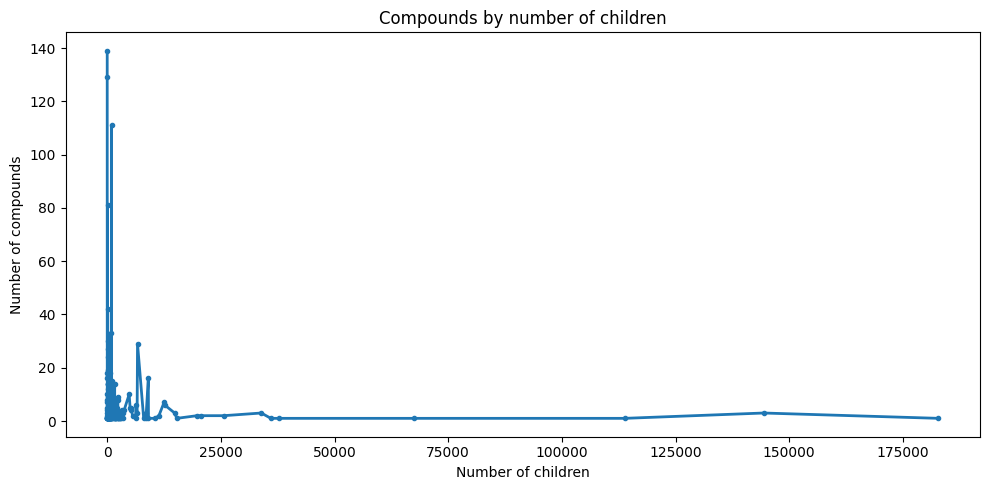

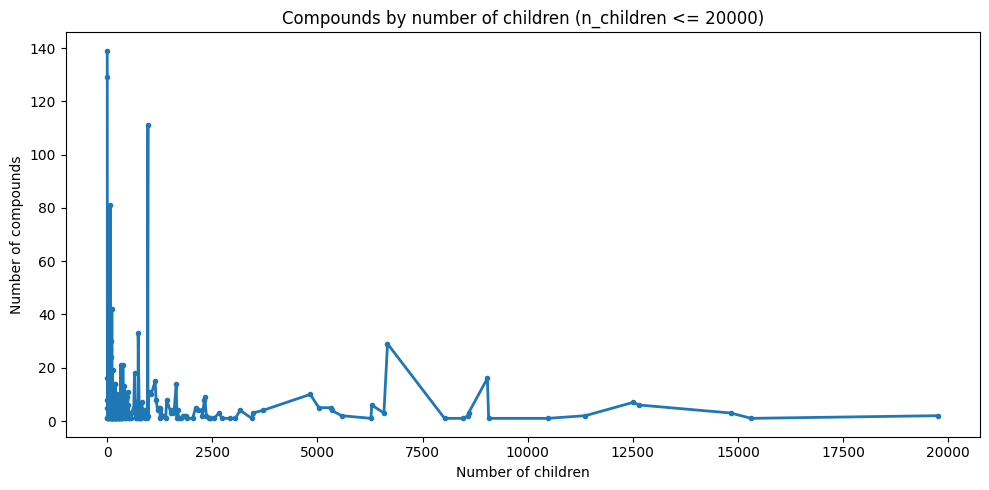

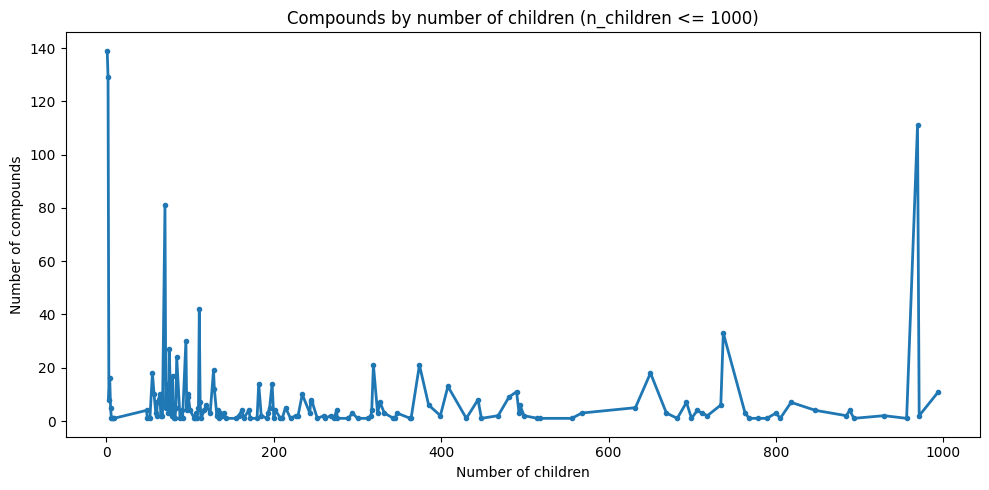

In [16]:
import matplotlib.pyplot as plt

if child_count_distribution.empty:
    print("No compounds found for the selected input.")
else:
    plt.figure(figsize=(10, 5))
    plt.plot(
        child_count_distribution["n_children"],
        child_count_distribution["n_compounds"],
        marker="o",
        markersize=3,
        linewidth=2
    )
    plt.xlabel("Number of children")
    plt.ylabel("Number of compounds")
    plt.title("Compounds by number of children")
    plt.tight_layout()
    plt.show()

    child_count_distribution_20000 = child_count_distribution[
        child_count_distribution["n_children"] <= 20000
    ]

    if child_count_distribution_20000.empty:
        print("No compounds found with n_children <= 20000.")
    else:
        plt.figure(figsize=(10, 5))
        plt.plot(
            child_count_distribution_20000["n_children"],
            child_count_distribution_20000["n_compounds"],
            marker="o",
            markersize=3,
            linewidth=2
        )
        plt.xlabel("Number of children")
        plt.ylabel("Number of compounds")
        plt.title("Compounds by number of children (n_children <= 20000)")
        plt.tight_layout()
        plt.show()

    child_count_distribution_1000 = child_count_distribution[
        child_count_distribution["n_children"] <= 1000
    ]

    if child_count_distribution_1000.empty:
        print("No compounds found with n_children <= 1000.")
    else:
        plt.figure(figsize=(10, 5))
        plt.plot(
            child_count_distribution_1000["n_children"],
            child_count_distribution_1000["n_compounds"],
            marker="o",
            markersize=3,
            linewidth=2
        )
        plt.xlabel("Number of children")
        plt.ylabel("Number of compounds")
        plt.title("Compounds by number of children (n_children <= 1000)")
        plt.tight_layout()
        plt.show()